# Thuật toán Clarke-Wright Savings cho bài toán City Vehicle Routing Problem (City VRP / VRPTW)

## Mục tiêu

Giải bài toán định tuyến xe bằng phương pháp Clarke-Wright Savings nhằm:

- Giảm tổng quãng đường
- Gom tuyến hiệu quả
- Tôn trọng tải trọng xe
- Tạo baseline heuristic để so sánh với ACO

## Dữ liệu đầu vào

- Tọa độ khách hàng (`x`, `y`)
- Nhu cầu (`demand`)
- Depot
- Sức chứa xe

## Kết quả đầu ra

- Tuyến đường tối ưu theo Savings
- Tổng quãng đường
- Số xe sử dụng
- Bản đồ tuyến đường

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# Tham số hệ thống
VEHICLE_CAPACITY = 15

# Nạp dữ liệu đầu vào và hiển thị thông tin hệ thống

In [2]:
df = pd.read_csv("vrptw_input.csv")

print("="*78)
print("THÔNG TIN DỮ LIỆU ĐẦU VÀO")
print("="*78)

print(f"- Số khách hàng        : {len(df)-1}")
print(f"- Depot                : ({df.iloc[0]['x']}, {df.iloc[0]['y']})")
print(f"- Sức chứa xe          : {VEHICLE_CAPACITY}")

print("\nDỮ LIỆU ĐẦU VÀO:\n")
print(df.to_string(index=False))

print("="*78)

df

THÔNG TIN DỮ LIỆU ĐẦU VÀO
- Số khách hàng        : 5
- Depot                : (50, 50)
- Sức chứa xe          : 15

DỮ LIỆU ĐẦU VÀO:

 id  x  y  demand  ready_time  due_time  service_time
  0 50 50       0           0       999             0
  1 10 20       5           0       150            10
  2 20 40       4          10       160            10
  3 60 30       6          20       180            10
  4 80 70       3          30       200            10
  5 40 60       2          40       220            10


,id,x,y,demand,ready_time,due_time,service_time
0,0,50,50,0,0,999,0
1,1,10,20,5,0,150,10
2,2,20,40,4,10,160,10
3,3,60,30,6,20,180,10
4,4,80,70,3,30,200,10
5,5,40,60,2,40,220,10


# Xây dựng ma trận khoảng cách và bảng Savings

In [8]:
def euclidean_distance(a, b):

    return math.sqrt((a['x'] - b['x'])**2 + (a['y'] - b['y'])**2)


n = len(df)

distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i][j] = euclidean_distance(df.iloc[i], df.iloc[j])


# Savings
savings_list = []

for i in range(1, n):

    for j in range(i + 1, n):

        saving = distance_matrix[0][i] + distance_matrix[0][j] - distance_matrix[i][j]

        savings_list.append((i, j, saving))


savings_list = sorted(savings_list, key=lambda x: x[2], reverse=True)

savings_df = pd.DataFrame(
    savings_list,
    columns=["Customer i", "Customer j", "Savings"]
)

savings_df

,Customer i,Customer j,Savings
0,1,2,59.262097
1,1,3,21.370485
2,2,5,17.480641
3,1,5,14.142136
4,3,4,13.694833
5,2,3,12.752400
6,4,5,8.966592
7,2,4,0.596250
8,3,5,0.447303
9,1,4,0.032260


# Thuật toán Clarke-Wright Savings (Core Merge Logic)

Cell này thực hiện:

- Khởi tạo mỗi khách là một tuyến riêng
- Tính tải trọng từng tuyến
- Ghép tuyến theo Savings lớn nhất
- Tôn trọng giới hạn tải trọng

In [9]:
# Khởi tạo: mỗi khách là 1 route riêng
routes = {i: [0, i, 0] for i in range(1, n)}

# Tải trọng route
route_loads = {i: df.iloc[i]['demand'] for i in range(1, n)}


# Clarke-Wright Merge
for i, j, saving in savings_list:

    route_i_key = None
    route_j_key = None

    # Tìm route chứa i ở cuối
    # Tìm route chứa j ở đầu
    for key, route in routes.items():

        if route[-2] == i:
            route_i_key = key

        if route[1] == j:
            route_j_key = key

    # Điều kiện ghép
    if (
        route_i_key is not None
        and route_j_key is not None
        and route_i_key != route_j_key
    ):

        combined_load = (
            route_loads[route_i_key]
            + route_loads[route_j_key]
        )

        # Không vượt tải trọng
        if combined_load <= VEHICLE_CAPACITY:

            # Ghép route_i + route_j
            new_route = (
                routes[route_i_key][:-1]
                + routes[route_j_key][1:]
            )

            # Update
            routes[route_i_key] = new_route
            route_loads[route_i_key] = combined_load

            del routes[route_j_key]
            del route_loads[route_j_key]


# Final routes
final_routes = list(routes.values())

print("TUYẾN CUỐI CÙNG:")
for route in final_routes:
    print(route)

TUYẾN CUỐI CÙNG:
[0, 1, 2, 5, 0]
[0, 3, 4, 0]


# Đánh giá kết quả, bảng tuyến đường và tổng kết hiệu suất

Cell này thực hiện:

- Tính quãng đường từng tuyến
- Tính tổng quãng đường toàn hệ thống
- Hiển thị bảng kết quả
- Tổng kết hiệu suất Clarke-Wright

In [10]:
# Hàm tính quãng đường
def calculate_route_distance(route):

    total_distance = 0

    for i in range(len(route) - 1):

        total_distance += distance_matrix[route[i]][route[i + 1]]

    return total_distance


# Bảng kết quả
results = []

total_cost = 0

for i, route in enumerate(final_routes):

    distance = calculate_route_distance(route)

    total_cost += distance

    results.append({
        "Xe (Vehicle)": i + 1,
        "Tuyến đường (Route)": " -> ".join(map(str, route)),
        "Quãng đường (Distance)": round(distance, 2)
    })


final_routes_df = pd.DataFrame(results)


# Tổng kết
summary_df = pd.DataFrame([{
    "Tổng quãng đường (Total Distance)": round(total_cost, 2),
    "Số xe sử dụng (Vehicles Used)": len(final_routes),
    "Số khách hàng (Customers)": len(df) - 1
}])


print("KẾT QUẢ CLARKE-WRIGHT SAVINGS")
print("="*70)
print("Total Distance:", round(total_cost, 2))
print("Routes:", final_routes)
print("="*70)

print("\nBẢNG TUYẾN ĐƯỜNG:")
display(final_routes_df)

print("\nTỔNG KẾT HIỆU SUẤT:")
display(summary_df)

KẾT QUẢ CLARKE-WRIGHT SAVINGS
Total Distance: 217.92
Routes: [[0, 1, 2, 5, 0], [0, 3, 4, 0]]

BẢNG TUYẾN ĐƯỜNG:


,Xe (Vehicle),Tuyến đường (Route),Quãng đường (Distance)
0,1,0 -> 1 -> 2 -> 5 -> 0,114.79
1,2,0 -> 3 -> 4 -> 0,103.14



TỔNG KẾT HIỆU SUẤT:


,Tổng quãng đường (Total Distance),Số xe sử dụng (Vehicles Used),Số khách hàng (Customers)
0,217.92,2,5


# Ghép tuyến theo Clarke-Wright Savings

Điều kiện:

- Hai khách ở hai tuyến khác nhau
- Không vượt quá tải trọng
- Ghép cuối tuyến này với đầu tuyến kia

In [6]:
for i, j, saving in savings_list:

    route_i_key = None
    route_j_key = None

    # Tìm route chứa i và j
    for key, route in routes.items():

        if route[1] == i and route[-2] == i:
            route_i_key = key

        if route[1] == j and route[-2] == j:
            route_j_key = key

    # Nếu khác route và hợp lệ
    if (
        route_i_key is not None
        and route_j_key is not None
        and route_i_key != route_j_key
    ):

        combined_load = route_loads[route_i_key] + route_loads[route_j_key]

        if combined_load <= VEHICLE_CAPACITY:

            # Ghép route
            new_route = (
                routes[route_i_key][:-1] +
                routes[route_j_key][1:]
            )

            # Cập nhật
            routes[route_i_key] = new_route
            route_loads[route_i_key] = combined_load

            del routes[route_j_key]
            del route_loads[route_j_key]

# Kết quả tuyến sau khi ghép (Merged Routes)

In [7]:
final_routes = list(routes.values())

print("TUYẾN SAU KHI GHÉP:")
for route in final_routes:
    print(route)

TUYẾN SAU KHI GHÉP:
[0, 1, 2, 0]
[0, 3, 4, 0]
[0, 5, 0]


# Bản đồ tuyến đường Clarke-Wright và xuất dữ liệu kết quả

Hiển thị:

- Depot
- Khách hàng
- Tuyến từng xe

Xuất:

- final_routes_clarke_wright.csv
- summary_clarke_wright.csv

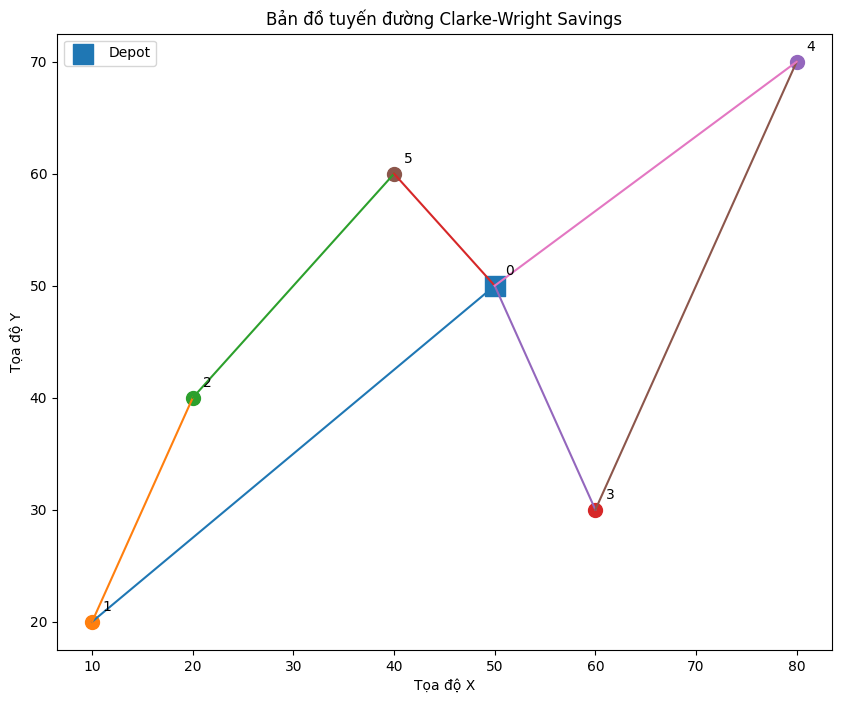

Đã xuất:
- final_routes_clarke_wright.csv
- summary_clarke_wright.csv


In [11]:
# Bản đồ tuyến đường
plt.figure(figsize=(10,8))

# Vẽ điểm
for i in range(len(df)):

    x = df.iloc[i]['x']
    y = df.iloc[i]['y']

    # Depot nổi bật hơn
    if i == 0:
        plt.scatter(x, y, s=200, marker='s', label='Depot')
    else:
        plt.scatter(x, y, s=100)

    plt.text(x + 1, y + 1, str(df.iloc[i]['id']))


# Vẽ tuyến
for route in final_routes:

    for i in range(len(route) - 1):

        x1 = df.iloc[route[i]]['x']
        y1 = df.iloc[route[i]]['y']

        x2 = df.iloc[route[i + 1]]['x']
        y2 = df.iloc[route[i + 1]]['y']

        plt.plot([x1, x2], [y1, y2])


plt.title("Bản đồ tuyến đường Clarke-Wright Savings")
plt.xlabel("Tọa độ X")
plt.ylabel("Tọa độ Y")

plt.legend()

plt.show()


# Export CSV
final_routes_df.to_csv("final_routes_clarke_wright.csv", index=False)

summary_df.to_csv("summary_clarke_wright.csv", index=False)


print("Đã xuất:")
print("- final_routes_clarke_wright.csv")
print("- summary_clarke_wright.csv")

# Kiểm tra tính tay chi tiết và phân tích tuyến Clarke-Wright

Mục tiêu:

- Phân tích từng chặng trong tuyến
- Tính khoảng cách từng bước
- Xác minh tổng quãng đường
- Chuẩn bị so sánh với ACO

In [14]:
# Chọn tuyến đầu tiên
sample_route = final_routes[0]


# Phân tích từng chặng
manual_steps = []

total_manual_distance = 0

for i in range(len(sample_route) - 1):

    start_node = sample_route[i]
    end_node = sample_route[i + 1]

    step_distance = distance_matrix[start_node][end_node]

    total_manual_distance += step_distance

    manual_steps.append({
        "Từ (From)": start_node,
        "Đến (To)": end_node,
        "Khoảng cách (Distance)": round(step_distance, 2)
    })


# DataFrame
manual_check_df = pd.DataFrame(manual_steps)


# Hiển thị
print("KIỂM TRA TÍNH TAY CHI TIẾT")
print("="*70)

print("Tuyến kiểm tra:")
print(" -> ".join(map(str, sample_route)))

print("\nBẢNG PHÂN TÍCH TỪNG CHẶNG:")
display(manual_check_df)

print("TỔNG QUÃNG ĐƯỜNG TÍNH TAY:")
print(round(total_manual_distance, 2))

print("\nĐỐI CHIẾU HÀM:")
function_distance = calculate_route_distance(sample_route)

print(round(function_distance, 2))


# Kết luận
if round(total_manual_distance, 2) == round(function_distance, 2):

    print("\nKẾT LUẬN: Chính xác — Tính tay khớp với hàm.")

else:

    print("\nKẾT LUẬN: Có sai lệch — Cần kiểm tra lại.")

KIỂM TRA TÍNH TAY CHI TIẾT
Tuyến kiểm tra:
0 -> 1 -> 2 -> 5 -> 0

BẢNG PHÂN TÍCH TỪNG CHẶNG:


,Từ (From),Đến (To),Khoảng cách (Distance)
0,0,1,50.00
1,1,2,22.36
2,2,5,28.28
3,5,0,14.14


TỔNG QUÃNG ĐƯỜNG TÍNH TAY:
114.79

ĐỐI CHIẾU HÀM:
114.79

KẾT LUẬN: Chính xác — Tính tay khớp với hàm.
